# Understand the Data

In [2]:
import sys
from pathlib import Path

print("Python:", sys.executable)
print("Current folder:", Path.cwd())

Python: c:\Users\lenovo\OneDrive\Desktop\Spotter_assesment\Assesment\.venv\Scripts\python.exe
Current folder: c:\Users\lenovo\OneDrive\Desktop\Spotter_assesment\Assesment\notebooks


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data" / "raw"

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)

Project root: c:\Users\lenovo\OneDrive\Desktop\Spotter_assesment\Assesment
Data directory: c:\Users\lenovo\OneDrive\Desktop\Spotter_assesment\Assesment\data\raw


In [4]:
files = {
    "train": DATA_DIR / "train-test.csv",
    "validation": DATA_DIR / "validation.csv",
    "template": DATA_DIR / "validation-predictions-template.csv",
    "december": DATA_DIR / "december-chart-inputs.csv",
}

for name, path in files.items():
    print(f"{name:12} | exists={path.exists()} | {path}")

train        | exists=True | c:\Users\lenovo\OneDrive\Desktop\Spotter_assesment\Assesment\data\raw\train-test.csv
validation   | exists=True | c:\Users\lenovo\OneDrive\Desktop\Spotter_assesment\Assesment\data\raw\validation.csv
template     | exists=True | c:\Users\lenovo\OneDrive\Desktop\Spotter_assesment\Assesment\data\raw\validation-predictions-template.csv
december     | exists=True | c:\Users\lenovo\OneDrive\Desktop\Spotter_assesment\Assesment\data\raw\december-chart-inputs.csv


In [5]:
train_df = pd.read_csv(files["train"])
validation_df = pd.read_csv(files["validation"])
template_df = pd.read_csv(files["template"])
december_df = pd.read_csv(files["december"])

print("Train shape:     ", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Template shape:  ", template_df.shape)
print("December shape:  ", december_df.shape)

Train shape:      (48000, 14)
Validation shape: (12000, 13)
Template shape:   (12000, 2)
December shape:   (31, 7)


In [6]:
print("TRAIN COLUMNS")
print(train_df.columns.tolist())

print("\nVALIDATION COLUMNS")
print(validation_df.columns.tolist())

print("\nTEMPLATE COLUMNS")
print(template_df.columns.tolist())

print("\nDECEMBER COLUMNS")
print(december_df.columns.tolist())

TRAIN COLUMNS
['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal', 'posted_rate']

VALIDATION COLUMNS
['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal']

TEMPLATE COLUMNS
['load_id', 'predicted_rate']

DECEMBER COLUMNS
['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']


## Data Inspection

In [7]:
print("TRAIN DATA")
train_df.info()

print("\n" + "=" * 80 + "\n")

print("VALIDATION DATA")
validation_df.info()

TRAIN DATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


VALIDATION DATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 13 columns):
 #   Column  

## Missing Values

In [8]:
missing_summary = pd.DataFrame({
    "train_missing": train_df.isna().sum(),
    "train_missing_pct": (train_df.isna().mean() * 100).round(2),
    "validation_missing": validation_df.isna().sum(),
    "validation_missing_pct": (validation_df.isna().mean() * 100).round(2),
})

display(missing_summary)

,train_missing,train_missing_pct,validation_missing,validation_missing_pct
date,0,0.00,0.0,0.00
delivery,0,0.00,0.0,0.00
delivery_lat,0,0.00,0.0,0.00
delivery_lon,0,0.00,0.0,0.00
distance,0,0.00,0.0,0.00
equipment,0,0.00,0.0,0.00
load_id,0,0.00,0.0,0.00
market_index,374,0.78,249.0,2.08
pickup,0,0.00,0.0,0.00
pickup_lat,0,0.00,0.0,0.00


## Duplicate Rows and Ids

In [9]:
print("Duplicate train rows:", train_df.duplicated().sum())
print("Duplicate validation rows:", validation_df.duplicated().sum())

print("\nTrain load_id duplicates:",
      train_df["load_id"].duplicated().sum())

print("Validation load_id duplicates:",
      validation_df["load_id"].duplicated().sum())

print("\nTrain missing load_id:",
      train_df["load_id"].isna().sum())

print("Validation missing load_id:",
      validation_df["load_id"].isna().sum())

print("\nUnique train IDs:",
      train_df["load_id"].nunique())

print("Unique validation IDs:",
      validation_df["load_id"].nunique())

Duplicate train rows: 0
Duplicate validation rows: 0

Train load_id duplicates: 0
Validation load_id duplicates: 0

Train missing load_id: 0
Validation missing load_id: 0

Unique train IDs: 48000
Unique validation IDs: 12000


In [10]:
numeric_cols = [
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "posted_rate",
]

display(train_df[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
pickup_lat,48000.0,35.647545,4.315285,28.35765,31.98691,35.29479,39.411040,44.30296
pickup_lon,48000.0,-90.928964,13.482431,-121.69849,-98.40059,-88.08915,-83.285060,-69.50000
delivery_lat,48000.0,35.641175,4.317199,28.35765,31.98691,35.29479,39.411040,44.30296
delivery_lon,48000.0,-90.857310,13.476589,-121.69849,-98.40059,-87.52871,-83.285060,-69.50000
distance,48000.0,1135.856654,728.564416,70.00000,550.40000,953.30000,1645.525000,3439.80000
weight,47700.0,31028.844004,9391.440620,-47500.00000,25800.00000,31436.50000,37018.000000,47500.00000
market_index,47626.0,1.083387,0.168091,0.67639,0.94967,1.05580,1.219590,1.46778
quote_signal,48000.0,2.062468,0.291391,0.69228,1.89103,2.05575,2.221685,3.61035
posted_rate,48000.0,2373.980682,1486.493245,57.22000,1251.55500,2030.76000,3330.750000,25533.00000


In [11]:
for col in ["distance", "weight", "posted_rate"]:
    print(
        f"{col:12} | "
        f"zero={(train_df[col] == 0).sum():5} | "
        f"negative={(train_df[col] < 0).sum():5}"
    )

distance     | zero=    0 | negative=    0
weight       | zero=    0 | negative=  292
posted_rate  | zero=    0 | negative=    0


## Inspecting dates without modifying orignals 

In [12]:
train_dates = pd.to_datetime(train_df["date"], errors="coerce")
validation_dates = pd.to_datetime(validation_df["date"], errors="coerce")
december_dates = pd.to_datetime(december_df["date"], errors="coerce")

print("TRAIN")
print("Invalid dates:", train_dates.isna().sum())
print("Start:", train_dates.min())
print("End:  ", train_dates.max())

print("\nVALIDATION")
print("Invalid dates:", validation_dates.isna().sum())
print("Start:", validation_dates.min())
print("End:  ", validation_dates.max())

print("\nDECEMBER")
print("Invalid dates:", december_dates.isna().sum())
print("Start:", december_dates.min())
print("End:  ", december_dates.max())

TRAIN
Invalid dates: 0
Start: 2025-01-01 00:00:00
End:   2025-10-31 00:00:00

VALIDATION
Invalid dates: 0
Start: 2025-11-01 00:00:00
End:   2025-12-31 00:00:00

DECEMBER
Invalid dates: 0
Start: 2025-12-01 00:00:00
End:   2025-12-31 00:00:00


## understand the target

In [13]:
display(train_df["posted_rate"].describe())

count    48000.000000
mean      2373.980682
std       1486.493245
min         57.220000
25%       1251.555000
50%       2030.760000
75%       3330.750000
max      25533.000000
Name: posted_rate, dtype: float64

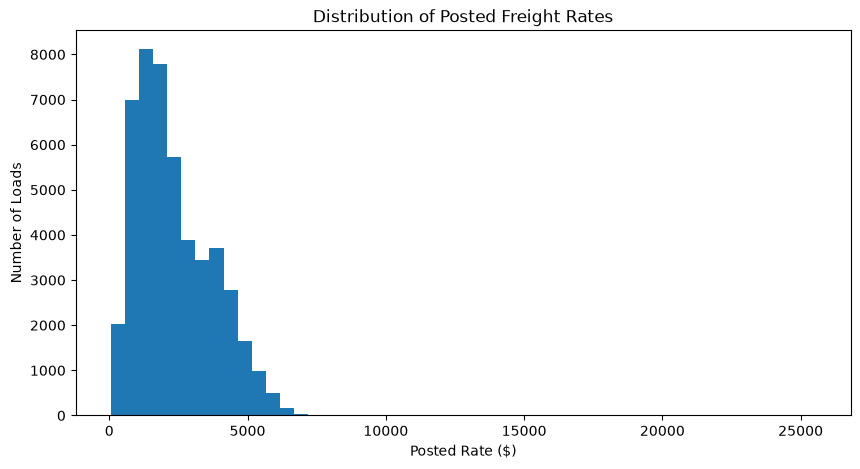

In [14]:
plt.figure(figsize=(10, 5))
plt.hist(train_df["posted_rate"], bins=50)
plt.title("Distribution of Posted Freight Rates")
plt.xlabel("Posted Rate ($)")
plt.ylabel("Number of Loads")
plt.show()

In [15]:
print("Median rate:", train_df["posted_rate"].median())
print("Mean rate:  ", train_df["posted_rate"].mean())
print("Min rate:   ", train_df["posted_rate"].min())
print("Max rate:   ", train_df["posted_rate"].max())

Median rate: 2030.76
Mean rate:   2373.9806822916667
Min rate:    57.22
Max rate:    25533.0


# understand the features

In [16]:
negative_weight_train = train_df[train_df["weight"] < 0]

print("Negative weights in train:", len(negative_weight_train))

display(
    negative_weight_train[
        [
            "load_id",
            "pickup",
            "delivery",
            "distance",
            "equipment",
            "weight",
            "posted_rate",
        ]
    ].head(20)
)

print("\nNegative weights in validation:",
      (validation_df["weight"] < 0).sum())

Negative weights in train: 292


,load_id,pickup,delivery,distance,equipment,weight,posted_rate
68,TR-000069,Amarillo,Dayton,1334.2,Reefer,-36559.0,2831.27
204,TR-000205,Fresno,Tucson,496.2,Dry Van,-26670.0,1046.92
206,TR-000207,Columbia,Raleigh,411.3,Reefer,-20003.0,959.15
225,TR-000226,Greensboro,Lubbock,1317.4,Reefer,-23981.0,2836.00
376,TR-000377,Madison,Providence,1331.1,Dry Van,-41397.0,2522.54
446,TR-000447,Albuquerque,Albany,2438.3,Reefer,-37215.0,4841.57
495,TR-000496,Montgomery,Dayton,715.9,Dry Van,-31214.0,1473.78
641,TR-000642,Tulsa,Indianapolis,582.4,Dry Van,-41023.0,1264.33
806,TR-000807,Cincinnati,Buffalo,676.1,Dry Van,-28320.0,1307.76
1093,TR-001094,Cincinnati,Albany,1058.5,Dry Van,-25153.0,1907.83



Negative weights in validation: 145


In [17]:
display(
    negative_weight_train["weight"]
    .abs()
    .describe()
)

count      292.000000
mean     31724.195205
std       8262.536326
min       5000.000000
25%      25928.500000
50%      31821.500000
75%      37284.250000
max      47500.000000
Name: weight, dtype: float64

## Examine categorical features

In [18]:
for col in ["pickup", "delivery", "equipment"]:
    print(f"\n--- {col.upper()} ---")
    print("Train unique:", train_df[col].nunique())
    print("Validation unique:", validation_df[col].nunique())

    print("\nMost common training values:")
    print(train_df[col].value_counts().head(10))


--- PICKUP ---
Train unique: 64
Validation unique: 72

Most common training values:
pickup
Oklahoma City    1242
Lexington        1209
Bakersfield      1193
Fort Wayne       1170
Hartford         1150
Richmond         1140
Nashville        1124
Phoenix          1121
Baton Rouge      1115
Mobile           1094
Name: count, dtype: int64

--- DELIVERY ---
Train unique: 64
Validation unique: 72

Most common training values:
delivery
Lexington        1197
Fort Wayne       1176
Baton Rouge      1167
Bakersfield      1156
Hartford         1143
Oklahoma City    1140
Richmond         1109
Atlanta          1096
Phoenix          1090
Mobile           1089
Name: count, dtype: int64

--- EQUIPMENT ---
Train unique: 3
Validation unique: 3

Most common training values:
equipment
Dry Van    27202
Reefer     12045
Flatbed     8753
Name: count, dtype: int64


In [19]:
for col in ["pickup", "delivery", "equipment"]:
    train_values = set(train_df[col].dropna())
    validation_values = set(validation_df[col].dropna())

    unseen = sorted(validation_values - train_values)

    print(f"{col}: {len(unseen)} unseen validation values")
    print(unseen[:20])
    print()

pickup: 8 unseen validation values
['Allentown', 'Charlotte', 'Chicago', 'Jackson', 'Knoxville', 'Laredo', 'Norfolk', 'San Diego']

delivery: 8 unseen validation values
['Allentown', 'Charlotte', 'Chicago', 'Jackson', 'Knoxville', 'Laredo', 'Norfolk', 'San Diego']

equipment: 0 unseen validation values
[]



## Numeric feature relationships with the target

In [20]:
numeric_target_cols = [
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "posted_rate",
]

correlations = (
    train_df[numeric_target_cols]
    .corr(numeric_only=True)["posted_rate"]
    .sort_values(ascending=False)
)

display(correlations)

posted_rate     1.000000
distance        0.908519
weight          0.034840
market_index    0.034165
quote_signal   -0.039858
pickup_lat     -0.090873
delivery_lat   -0.091970
pickup_lon     -0.255058
delivery_lon   -0.257086
Name: posted_rate, dtype: float64

##  distance vs freight rate

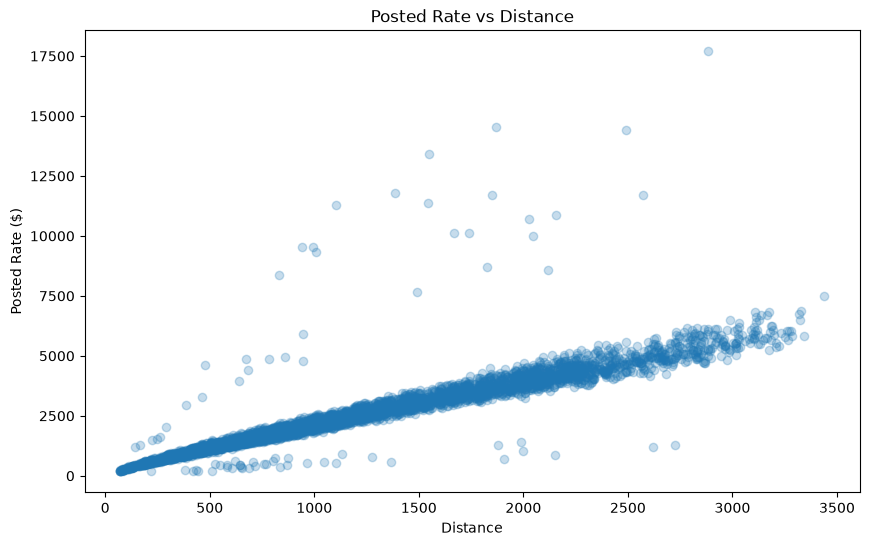

In [21]:
sample_df = train_df.sample(
    n=min(5000, len(train_df)),
    random_state=42
)

plt.figure(figsize=(10, 6))
plt.scatter(
    sample_df["distance"],
    sample_df["posted_rate"],
    alpha=0.25
)

plt.title("Posted Rate vs Distance")
plt.xlabel("Distance")
plt.ylabel("Posted Rate ($)")
plt.show()

## Create a temporary rate-per-mile diagnostic

In [22]:
train_df["rate_per_mile_eda"] = (
    train_df["posted_rate"] / train_df["distance"]
)

display(train_df["rate_per_mile_eda"].describe())

count    48000.000000
mean         2.215347
std          0.583887
min          0.333709
25%          1.986974
50%          2.145348
75%          2.342696
max         14.125294
Name: rate_per_mile_eda, dtype: float64

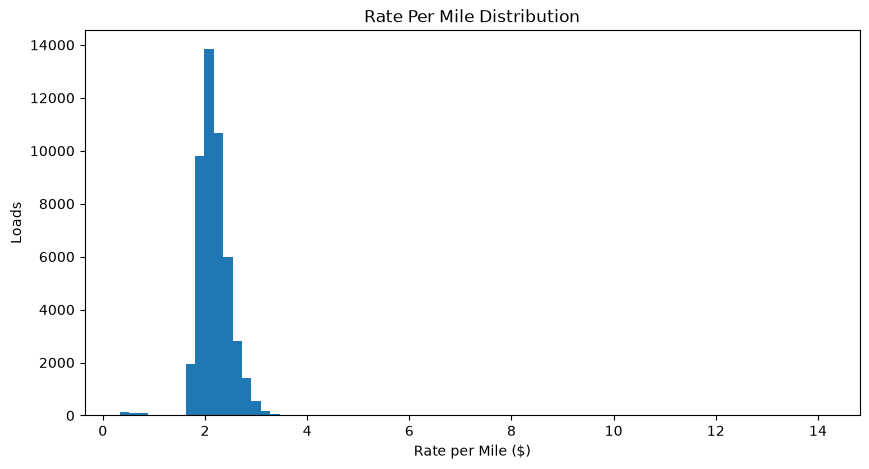

In [23]:
plt.figure(figsize=(10, 5))
plt.hist(
    train_df["rate_per_mile_eda"],
    bins=75
)

plt.title("Rate Per Mile Distribution")
plt.xlabel("Rate per Mile ($)")
plt.ylabel("Loads")
plt.show()

## Equipment vs freight rate

In [24]:
equipment_summary = (
    train_df
    .groupby("equipment")["posted_rate"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("median", ascending=False)
)

display(equipment_summary)

,count,mean,median,std
equipment,,,,
Reefer,12045,2553.636939,2196.670,1589.670824
Flatbed,8753,2445.087223,2076.810,1505.053087
Dry Van,27202,2271.548686,1953.035,1423.029914


## Monthly target trend

In [25]:
eda_dates = pd.to_datetime(train_df["date"])

monthly_rates = (
    train_df
    .assign(month=eda_dates.dt.to_period("M").astype(str))
    .groupby("month")["posted_rate"]
    .agg(["count", "mean", "median"])
)

display(monthly_rates)

,count,mean,median
month,,,
2025-01,4918,2255.967048,1915.200
2025-02,4337,2273.804801,1994.250
2025-03,5036,2372.268092,2022.920
2025-04,4819,2372.162308,2044.240
2025-05,4913,2421.776342,2065.510
2025-06,4783,2497.030115,2120.220
2025-07,4912,2415.162030,2059.145
2025-08,4759,2338.407661,2015.730
2025-09,4670,2406.374013,2057.130


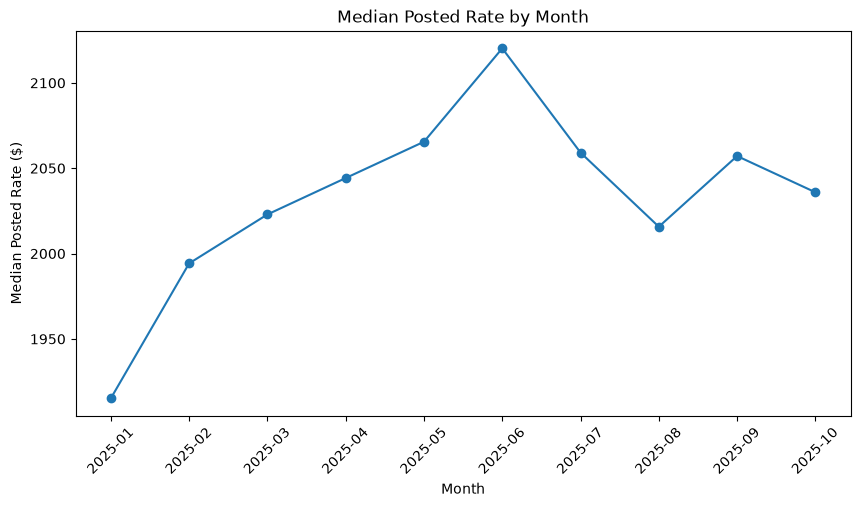

In [26]:
plt.figure(figsize=(10, 5))
plt.plot(
    monthly_rates.index,
    monthly_rates["median"],
    marker="o"
)

plt.title("Median Posted Rate by Month")
plt.xlabel("Month")
plt.ylabel("Median Posted Rate ($)")
plt.xticks(rotation=45)
plt.show()

# Preprocessing Decisions

In [27]:
train_clean = train_df.copy()
validation_clean = validation_df.copy()
december_clean = december_df.copy()

print("Train:", train_clean.shape)
print("Validation:", validation_clean.shape)
print("December:", december_clean.shape)

Train: (48000, 15)
Validation: (12000, 13)
December: (31, 7)


In [28]:
def basic_cleaning(df):
    df = df.copy()

    # Parse date
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    # Preserve information about missing weight before imputation
    df["weight_missing"] = df["weight"].isna().astype(int)

    # Correct sign-corrupted weights
    df["weight"] = df["weight"].abs()

    # Calendar features
    df["month"] = df["date"].dt.month
    df["day_of_week"] = df["date"].dt.dayofweek
    df["day_of_month"] = df["date"].dt.day
    df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)

    return df

In [29]:
train_clean = basic_cleaning(train_clean)
validation_clean = basic_cleaning(validation_clean)
december_clean = basic_cleaning(december_clean)

In [30]:
print("TRAIN")
print("Negative weights:", (train_clean["weight"] < 0).sum())
print("Missing weights:", train_clean["weight"].isna().sum())

print("\nVALIDATION")
print("Negative weights:", (validation_clean["weight"] < 0).sum())
print("Missing weights:", validation_clean["weight"].isna().sum())

print("\nDECEMBER")
print("Negative weights:", (december_clean["weight"] < 0).sum())
print("Missing weights:", december_clean["weight"].isna().sum())

TRAIN
Negative weights: 0
Missing weights: 300

VALIDATION
Negative weights: 0
Missing weights: 165

DECEMBER
Negative weights: 0
Missing weights: 0


In [31]:
display(
    train_clean[
        [
            "date",
            "month",
            "day_of_week",
            "day_of_month",
            "week_of_year",
            "weight",
            "weight_missing",
        ]
    ].head()
)

,date,month,day_of_week,day_of_month,week_of_year,weight,weight_missing
0,2025-01-01,1,2,1,1,30658.0,0
1,2025-01-01,1,2,1,1,17555.0,0
2,2025-01-01,1,2,1,1,31721.0,0
3,2025-01-01,1,2,1,1,32333.0,0
4,2025-01-01,1,2,1,1,35183.0,0


In [32]:
# Remove EDA-only target-derived feature from modeling data
train_clean = train_clean.drop(
    columns=["rate_per_mile_eda"],
    errors="ignore"
)

print("rate_per_mile_eda exists:",
      "rate_per_mile_eda" in train_clean.columns)

print("Train columns:", train_clean.shape)

rate_per_mile_eda exists: False
Train columns: (48000, 19)


## Chronological Validation Split

In [33]:
print("Development date range:")
print(train_clean["date"].min(), "to", train_clean["date"].max())

print("\nRows per month:")
print(
    train_clean["date"]
    .dt.to_period("M")
    .value_counts()
    .sort_index()
)

Development date range:
2025-01-01 00:00:00 to 2025-10-31 00:00:00

Rows per month:
date
2025-01    4918
2025-02    4337
2025-03    5036
2025-04    4819
2025-05    4913
2025-06    4783
2025-07    4912
2025-08    4759
2025-09    4670
2025-10    4853
Freq: M, Name: count, dtype: int64


In [34]:
split_date = pd.Timestamp("2025-10-01")

dev_train = train_clean[
    train_clean["date"] < split_date
].copy()

dev_valid = train_clean[
    train_clean["date"] >= split_date
].copy()

print("Training period:")
print(dev_train["date"].min(), "to", dev_train["date"].max())
print("Rows:", len(dev_train))

print("\nInternal validation period:")
print(dev_valid["date"].min(), "to", dev_valid["date"].max())
print("Rows:", len(dev_valid))

Training period:
2025-01-01 00:00:00 to 2025-09-30 00:00:00
Rows: 43147

Internal validation period:
2025-10-01 00:00:00 to 2025-10-31 00:00:00
Rows: 4853


In [35]:
weight_median = dev_train["weight"].median()
market_index_median = dev_train["market_index"].median()

print("Training weight median:", weight_median)
print("Training market_index median:", market_index_median)

Training weight median: 31495.0
Training market_index median: 1.08317


In [36]:
for df in [dev_train, dev_valid]:
    df["market_index_missing"] = (
        df["market_index"].isna().astype(int)
    )

In [37]:
print("DEV TRAIN")
print("Missing weight:", dev_train["weight"].isna().sum())
print("Missing market_index:",
      dev_train["market_index"].isna().sum())

print("\nDEV VALID")
print("Missing weight:", dev_valid["weight"].isna().sum())
print("Missing market_index:",
      dev_valid["market_index"].isna().sum())

DEV TRAIN
Missing weight: 268
Missing market_index: 332

DEV VALID
Missing weight: 32
Missing market_index: 42


In [38]:
# Missing-value indicators
for df in [dev_train, dev_valid]:
    df["market_index_missing"] = df["market_index"].isna().astype(int)

# Impute using statistics learned ONLY from dev_train
weight_median = dev_train["weight"].median()
market_index_median = dev_train["market_index"].median()

dev_train["weight"] = dev_train["weight"].fillna(weight_median)
dev_valid["weight"] = dev_valid["weight"].fillna(weight_median)

dev_train["market_index"] = dev_train["market_index"].fillna(
    market_index_median
)

dev_valid["market_index"] = dev_valid["market_index"].fillna(
    market_index_median
)

print("Weight median:", weight_median)
print("Market index median:", market_index_median)

Weight median: 31495.0
Market index median: 1.08317


In [39]:
print("DEV TRAIN")
print("Missing weight:", dev_train["weight"].isna().sum())
print(
    "Missing market_index:",
    dev_train["market_index"].isna().sum()
)

print("\nDEV VALID")
print("Missing weight:", dev_valid["weight"].isna().sum())
print(
    "Missing market_index:",
    dev_valid["market_index"].isna().sum()
)

DEV TRAIN
Missing weight: 0
Missing market_index: 0

DEV VALID
Missing weight: 0
Missing market_index: 0


In [40]:
print("Train original missing weights:",
      dev_train["weight_missing"].sum())

print("Train original missing market_index:",
      dev_train["market_index_missing"].sum())

print("Valid original missing weights:",
      dev_valid["weight_missing"].sum())

print("Valid original missing market_index:",
      dev_valid["market_index_missing"].sum())

Train original missing weights: 268
Train original missing market_index: 332
Valid original missing weights: 32
Valid original missing market_index: 42


## a continuous time feature

In [41]:
DATE_ORIGIN = pd.Timestamp("2025-01-01")

for df in [dev_train, dev_valid]:
    df["days_since_start"] = (
        df["date"] - DATE_ORIGIN
    ).dt.days

print(
    dev_train["days_since_start"].min(),
    dev_train["days_since_start"].max()
)

print(
    dev_valid["days_since_start"].min(),
    dev_valid["days_since_start"].max()
)

0 272
273 303


# Baseline Model

In [42]:
numeric_features = [
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "month",
    "day_of_week",
    "day_of_month",
    "week_of_year",
    "days_since_start",
    "weight_missing",
    "market_index_missing",
]

categorical_features = [
    "pickup",
    "delivery",
    "equipment",
]

feature_columns = numeric_features + categorical_features

X_train = dev_train[feature_columns].copy()
y_train = dev_train["posted_rate"].copy()

X_valid = dev_valid[feature_columns].copy()
y_valid = dev_valid["posted_rate"].copy()

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)

X_train: (43147, 18)
X_valid: (4853, 18)
y_train: (43147,)
y_valid: (4853,)


In [43]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

naive_prediction = np.full(
    len(y_valid),
    y_train.median()
)

naive_mae = mean_absolute_error(
    y_valid,
    naive_prediction
)

naive_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        naive_prediction
    )
)

naive_r2 = r2_score(
    y_valid,
    naive_prediction
)

print("Naive median baseline")
print(f"MAE:  ${naive_mae:,.2f}")
print(f"RMSE: ${naive_rmse:,.2f}")
print(f"R²:   {naive_r2:.4f}")

Naive median baseline
MAE:  $1,146.79
RMSE: $1,567.97
R²:   -0.0522


In [44]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

In [45]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features,
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features,
        ),
    ],
    remainder="drop",
)

In [46]:
ridge_baseline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            Ridge(alpha=1.0)
        ),
    ]
)

In [47]:
ridge_baseline.fit(
    X_train,
    y_train
)

print("Training complete.")

Training complete.


In [48]:
ridge_predictions = ridge_baseline.predict(
    X_valid
)

print("Predictions:", len(ridge_predictions))
print("Minimum prediction:", ridge_predictions.min())
print("Maximum prediction:", ridge_predictions.max())

Predictions: 4853
Minimum prediction: 78.16662924046204
Maximum prediction: 6575.163124702001


In [49]:
ridge_mae = mean_absolute_error(
    y_valid,
    ridge_predictions
)

ridge_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        ridge_predictions
    )
)

ridge_r2 = r2_score(
    y_valid,
    ridge_predictions
)

print("Ridge Regression — October Holdout")
print(f"MAE:  ${ridge_mae:,.2f}")
print(f"RMSE: ${ridge_rmse:,.2f}")
print(f"R²:   {ridge_r2:.4f}")

Ridge Regression — October Holdout
MAE:  $141.81
RMSE: $651.27
R²:   0.8185


In [50]:
results = pd.DataFrame({
    "model": [
        "Naive Median",
        "Ridge Regression",
    ],
    "MAE": [
        naive_mae,
        ridge_mae,
    ],
    "RMSE": [
        naive_rmse,
        ridge_rmse,
    ],
    "R2": [
        naive_r2,
        ridge_r2,
    ],
})

display(results)

,model,MAE,RMSE,R2
0,Naive Median,1146.793707,1567.970485,-0.052235
1,Ridge Regression,141.808856,651.267175,0.818467
